# Machine Learning Prediction of Diabetes from Clinical Data

## Project goal
This notebook predicts diabetes from patient clinical measurements using machine learning.

## Learning objectives
For a beginner, this notebook demonstrates the full workflow:
1. Load the dataset
2. Clean the data
3. Split the data into training and test sets
4. Train classification models
5. Evaluate the models
6. Plot ROC curves
7. Interpret the best model using feature importance

## Dataset
Pima Indians Diabetes Dataset  
Clinical variables include:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age

Target:
- Outcome (0 = no diabetes, 1 = diabetes)


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

PROJECT_DIR = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RAW_PATH = PROJECT_DIR / "data" / "raw" / "pima_indians_diabetes.csv"
RAW_PATH

PosixPath('/mnt/g/Genetic_Insight_Center/Top_Bioinformatics_Projects/Project5/data/raw/pima_indians_diabetes.csv')

## 1. Load the raw clinical dataset

We begin by loading the raw diabetes dataset and checking its structure.


In [2]:
df = pd.read_csv(RAW_PATH)
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset shape: (768, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Clean the dataset

Some columns contain impossible zeros that are treated as missing values:
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

We replace these zeros with missing values (`NaN`) and fill them using the median of each column.


In [3]:
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Zero counts before cleaning:")
print((df[zero_as_missing_cols] == 0).sum())

df_clean = df.copy()
df_clean[zero_as_missing_cols] = df_clean[zero_as_missing_cols].replace(0, np.nan)

print("\nMissing values after replacement:")
print(df_clean.isna().sum())

median_values = df_clean[zero_as_missing_cols].median()
df_clean[zero_as_missing_cols] = df_clean[zero_as_missing_cols].fillna(median_values)

print("\nMedian values used:")
print(median_values)

print("\nMissing values after imputation:")
print(df_clean.isna().sum())

df_clean.head()

Zero counts before cleaning:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after replacement:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Median values used:
Glucose          117.0
BloodPressure     72.0
SkinThickness     29.0
Insulin          125.0
BMI               32.3
dtype: float64

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## 3. Split into features and target

`X` contains the clinical predictors and `y` contains the diabetes outcome.
Then we split the dataset into:
- **Training set**: used to train the models
- **Test set**: used to evaluate the models fairly


In [4]:
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

X_train shape: (614, 8)
X_test shape: (154, 8)

Training class distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Test class distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


## 4. Train machine-learning classification models

We train three models:
- Logistic Regression
- Random Forest
- Support Vector Machine

Logistic Regression and SVM use feature scaling because their performance depends on feature magnitudes.


In [5]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),
    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(probability=True, random_state=42))
    ])
}

for name, model in models.items():
    model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


## 5. Evaluate the models

We calculate:
- Accuracy
- Precision
- Recall / Sensitivity
- Specificity
- F1-score
- ROC-AUC

These metrics help us judge performance from different clinical perspectives.


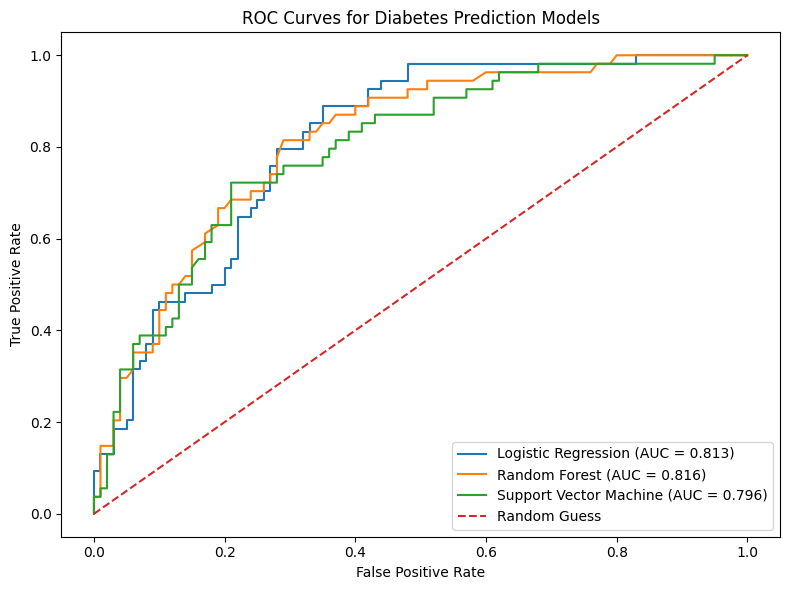

,model,accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,true_negative,false_positive,false_negative,true_positive
1,Random Forest,0.746753,0.666667,0.555556,0.85,0.606061,0.816019,85,15,24,30
0,Logistic Regression,0.707792,0.600000,0.500000,0.82,0.545455,0.812963,82,18,27,27
2,Support Vector Machine,0.740260,0.652174,0.555556,0.84,0.600000,0.796389,84,16,24,30


In [6]:
metrics_rows = []

plt.figure(figsize=(8, 6))

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    sensitivity = recall_score(y_test, y_pred)
    specificity = tn / (tn + fp)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    metrics_rows.append({
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall_sensitivity": sensitivity,
        "specificity": specificity,
        "f1_score": f1,
        "roc_auc": auc,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
    })

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Diabetes Prediction Models")
plt.legend()
plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame(metrics_rows).sort_values(by="roc_auc", ascending=False)
metrics_df

## 6. Interpret the best model using feature importance

Since Random Forest performed best, we examine its feature importance values.


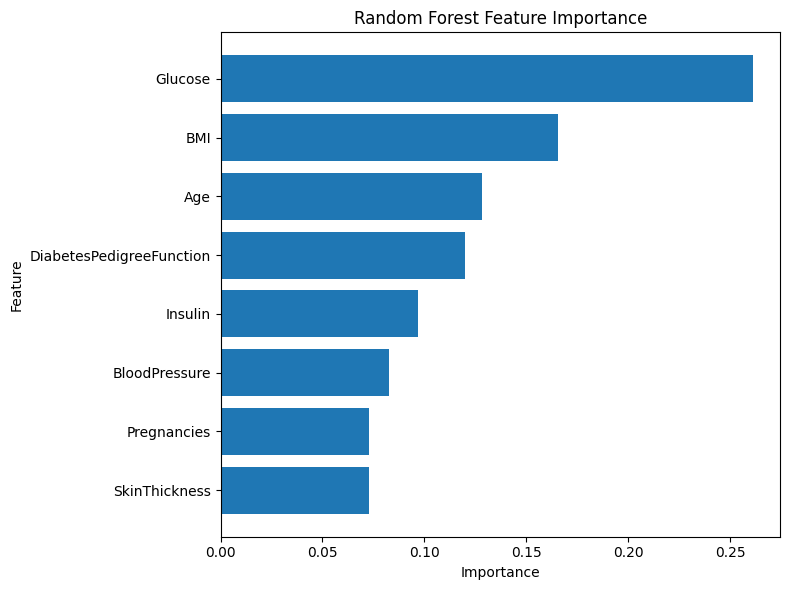

,feature,importance
1,Glucose,0.261296
5,BMI,0.165522
7,Age,0.128272
6,DiabetesPedigreeFunction,0.119705
4,Insulin,0.096891
2,BloodPressure,0.082373
0,Pregnancies,0.073029
3,SkinThickness,0.072913


In [7]:
rf_model = models["Random Forest"]
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

importance_df

## 7. Conclusion

In this project, we used clinical measurements to predict diabetes risk.  
We compared multiple classification models and found that **Random Forest** performed best in our current test split.  
Feature importance analysis showed that **Glucose**, **BMI**, and **Age** were among the most informative predictors.

This notebook is reproducible and can be rerun from start to finish by anyone with the required environment.
